# Logistic Regression


Logistic Regression is a classification model that models a probability.

It first calculates the linear score:

$$ z=\theta_0+\theta_1x_1+\theta_2x_2 $$

and then converts this into a probability using the sigmoid function:

$$ \sigma(z)=\frac{1}{1+e^{-z}} $$

solver: {‘lbfgs’, ‘liblinear’, ‘newton-cg’, ‘newton-cholesky’, ‘sag’, ‘saga’}, default=’lbfgs’ is an algorithm to use in the optimization problem. Default is ‘lbfgs’, 'lbfgs' stands for Limited-memory Broyden-Fletcher-Goldfarb-Shanno.

To choose a solver, you might want to consider some aspects.

‘lbfgs’ is a good default solver because it works reasonably well for a wide class of problems.

In scikit-learn, `C` controls the strength of the regularization—more precisely, it's the inverse regularization parameter.

This means:

$$ C \uparrow \quad\Rightarrow\quad \text{Regularization} \downarrow $$

and turns around:

$$ C \downarrow \quad\Rightarrow\quad \text{Regularization} \uparrow $$

'random_state' detemines a fixed random state, it's used for reproducibility.

When an algorithm uses a random, the result can change lightly without fixed seed

Access scikit-learn.org for more information

In [296]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sympy.abc import epsilon

Import dataset iris from sklearn

In [297]:
from sklearn import datasets
iris = datasets.load_iris()

# The Iris Dataset

This data sets consists of 3 different types of irises’ (Setosa, Versicolour, and Virginica) petal and sepal length, stored in a 150x4 numpy.ndarray

The rows being the samples and the columns being: Sepal Length, Sepal Width, Petal Length and Petal Width

In [298]:
print(iris.data[:4])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]]


Take the featrure Petal Length

In [299]:
x = iris.data[:, 2]
x = x.reshape(-1,1)

Change the original classification problem:

class 2 → 1

all another classes → 0

In [300]:
y = (iris.target == 2).astype(int)
print(y)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1]


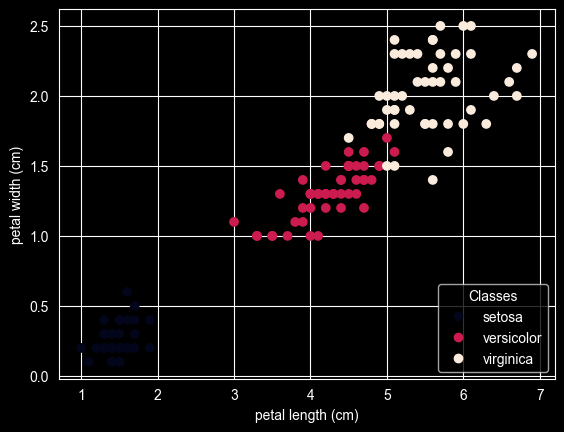

In [301]:
_, ax = plt.subplots()
scatter = ax.scatter(iris.data[:, 2], iris.data[:, 3], c=iris.target)
ax.set(xlabel=iris.feature_names[2], ylabel=iris.feature_names[3])
_ = ax.legend(
    scatter.legend_elements()[0], iris.target_names, loc="lower right", title="Classes"
)

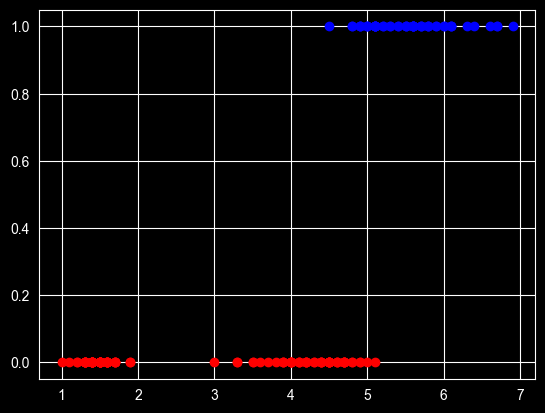

In [302]:
plt.scatter(x[y==0], y[y==0], color="red")
plt.scatter(x[y==1], y[y==1], color="blue")

In [303]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(solver="lbfgs", random_state=26)

log_reg.fit(x, y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",26
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

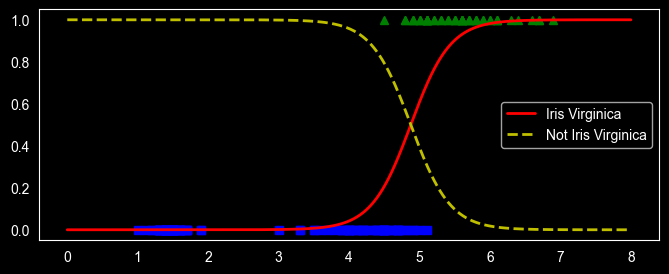

In [304]:
x_new = np.linspace(0, 8, 2000).reshape(-1, 1)
y_proba = log_reg.predict_proba(x_new)

plt.figure(figsize=(8, 3))
plt.plot(x[y==0], y[y==0], "bs")
plt.plot(x[y==1], y[y==1], "g^")
plt.plot(x_new, y_proba[:, 1], "r-", linewidth=2, label="Iris Virginica")
plt.plot(x_new, y_proba[:, 0], "y--", linewidth=2, label="Not Iris Virginica")
plt.grid(False)
plt.legend()

In [305]:
decision_boundary = x_new[y_proba[:, 1] >= 0.5][0]
decision_boundary

array([4.87843922])

In [306]:
log_reg.predict([[4.878], [1.2]])

array([1, 0])

After training model the modelparameter \{theta} would be found, so that

$$ P(y=1\mid x) = \sigma(\theta_0+\theta_1x_1+\theta_2x_2) $$

should fit the training data as closely as possible

These parameters are listed after `fit()`, among others:

`log_reg.coef_` (weights) and `log_reg.intercept_` (bias)

x-coordinates are defined with (2.9, 7), mean the left and rights edge of diagram
The decision boundary should be between these two points.

Our logistic regression is: $$ P(y=1|x) = \sigma(z) $$

with: $$ z= \theta_0+\theta_1x_1+\theta_2x_2 $$

Here:

`\theta_0` = Intercept

`\theta_1` = Coefficient for Petal Length

`\theta_2` = Coefficient for Petal Width

In logistic regression, the following is typically used: $$ P(y=1)=0.5 $$ as the limit.

Because the sigmoid function satisfies: $$ \sigma(0)=0.5 $$

Therefore: $$ P(y=1)=0.5 $$

correctly corresponds to: $$ z=0 $$

So: $$ \theta_0+\theta_1x_1+\theta_2x_2=0 $$

$$ x_2 = -\frac{\theta_1x_1+\theta_0}{\theta_2} $$

That is decision limit.


(np.float64(2.9), np.float64(7.0), np.float64(0.8), np.float64(2.7))

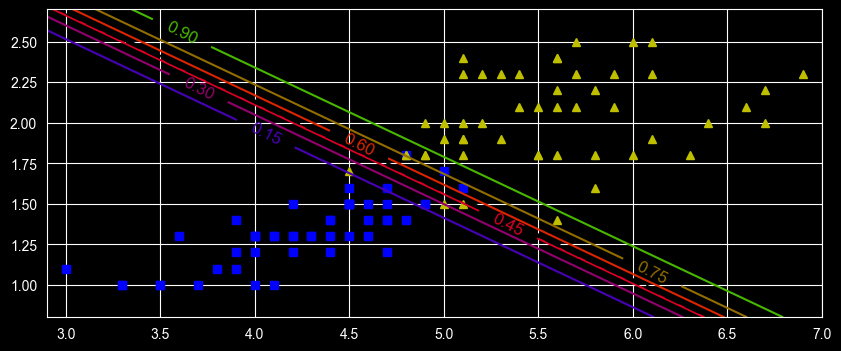

In [307]:
x = iris.data[:, (2, 3)] # take the columns Petal Length and Petal Width
y = (iris.target == 2).astype(int)
log_reg = LogisticRegression(solver="lbfgs", C=10**10, random_state=26)
log_reg.fit(x, y) # Training

# generate a 2-dimensional grid from many possible combinations of petal length and petal width to find out:
# what would the model predict for every point in this entire range
x0, x1 = np.meshgrid(np.linspace(2.9, 7, 500).reshape(-1, 1), # (500,1)
                     np.linspace(0.8, 2.7, 200).reshape(-1, 1)) # (200, 1) -> (200, 500)

# the grid is reshaped into a form that the ML model can work with.
x_new = np.c_[x0.ravel(), x1.ravel()] # revel(): from (200, 500) -> to 1-D vector (100000)-elements,
# [x0.ravel(), x1.ravel()].shape = (100000, 2) - (number of samples, number of features)

# to predict: fpr each sample in this 100000 points, what is the probability of class 0 or class 1?
y_proba = log_reg.predict_proba(x_new)

plt.figure(figsize=(10, 4)) # in zoll
plt.plot(x[y==0, 0], x[y==0, 1], "bs") # all flowers not virginica (column 0 = petal length, column 1 = petal width)
plt.plot(x[y==1, 0], x[y==1, 1], "y^") # all flowers virginica (column 0 = petal length, column 1 = petal width)

# take probability P(y=1): all rows, 2 columns and reshape to the original grid (200x500)
zz = y_proba[:, 1].reshape(x0.shape)

# generates contour lines
# A contour line contains all points:(x1,x2)
# for which the predicted probability is constant.
# For example: P(y=1|x) = 0.5  is a specific line.
# Another line could be: P(y=1|x)=0.75
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg) # brg = blue → red → green

left_right = np.array([2.9, 7])
# log_reg.coef_[0][0]   → theta1
# log_reg.coef_[0][1]   → theta2
# log_reg.intercept_[0] → theta0
boundary = -(log_reg.coef_[0][0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0][1]

# With the values of contour lines we know which probability does the model predict at this point
plt.clabel(contour, inline=1, fontsize=12)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.axis([2.9, 7, 0.8, 2.7])

# Logistic Regression with Gradient Descent

In [308]:
x = iris["data"][:, (2, 3)]  # petal length, petal width
y = iris["target"]

In [309]:
x_b = np.c_[np.ones([len(x), 1]), x]

Split train/validation/test using train_test_split from sklearn

In [310]:
from sklearn.model_selection import train_test_split

# Use train_test_split twice to split dataset into train, validation, test set with ratio 0.6, 0.2, 0.2
x_train, x_test, y_train, y_test = train_test_split(x_b, y, test_size=0.2)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25)


In [311]:
print(x_train.shape, x_val.shape, x_test.shape)

(90, 3) (30, 3) (30, 3)


In [312]:
np.unique(y)
num_class = np.unique(y).size
print(num_class)

3


The targets are currently class indices (0, 1, 2, ...), but we need target class probabilities to train the Softmax Regression model. Each instance will have target class probabilities equal to 0.0 for all classes except for the target class which will have a probability of 1.0. We need to convert the vector of class indices into a matrix containing a one-hot vector for each instance

The relationship

$$ X \;\xrightarrow{\text{weights }\Theta}\; Z=X\Theta \;\xrightarrow{\text{softmax}}\; \hat Y \;\xrightarrow{\text{cross-entropy}}\; L \;\xrightarrow{\text{gradient}}\; \Theta_{\text{new}} $$

In [313]:
def to_one_hot(y):
    y = y.astype(int)
    n_class = num_class
    m = len(y)
    y_one_hot = np.zeros((m, n_class))
    #print(y)
    y_one_hot[np.arange(m), y] = 1
    #print(y_one_hot)
    return y_one_hot

In [314]:
y_train_one_hot = to_one_hot(y_train)
y_val_one_hot = to_one_hot(y_val)
y_test_one_hot = to_one_hot(y_test)

We can use `OneHotEncoder` in `sklearn.preprocessing` to convert labels like above

In [315]:
from sklearn.preprocessing import OneHotEncoder
y_train_onehot = OneHotEncoder().fit_transform(y_train.reshape(-1, 1)).toarray()
#print(y_train_onehot)

Softmax is defined by thefollowing equation:

$$\sigma\left(\mathbf{s}(\mathbf{x})\right)_k = \dfrac{\exp\left(s_k(\mathbf{x})\right)}{\sum\limits_{j=1}^{K}{\exp\left(s_j(\mathbf{x})\right)}}$$

In [316]:
def softmax(logits):
    exps = np.exp(logits)
    exp_sums = np.sum(exps, axis=1, keepdims=True)
    return exps / exp_sums

The equations we will need are the cost function:

$J(\mathbf{\Theta}) = -\dfrac{1}{m}\sum\limits_{i=1}^{m}\sum\limits_{k=1}^{K}{y_k^{(i)}\log\left(\hat{p}_k^{(i)}\right)}$

And the equation for the gradients:

$\nabla_{\mathbf{\theta}^{(k)}} \, J(\mathbf{\Theta}) = \dfrac{1}{m} \sum\limits_{i=1}^{m}{ \left ( \hat{p}^{(i)}_k - y_k^{(i)} \right ) \mathbf{x}^{(i)}}$

Note that $\log\left(\hat{p}_k^{(i)}\right)$ may not be computable if $\hat{p}_k^{(i)} = 0$. So we will add a tiny value $\epsilon$ to $\log\left(\hat{p}_k^{(i)}\right)$ to avoid getting nan values.

In [317]:
logits = np.array([0.15, 0.3, -0.5]).reshape(1, 3)
p = softmax(logits)
y_true = np.array([0, 1, 0])
print(f"Probability score {p}")
print(f"Loss {-np.sum(y_true*np.log(p))}")

Probability score [[0.3725949  0.43289351 0.19451159]]
Loss 0.8372635159825825


In [318]:
n_inputs = x_train.shape[1]
n_outputs = y_train_one_hot.shape[1]
print(n_inputs, n_outputs)

3 3


## The Complete Mathematical Algorithm of Gradient Descent

Initialization
$$ \Theta^{(0)} \sim \mathcal N(0,1) $$

For each iteration \(t\):

Step 1: Logits
$$ \boxed{ Z^{(t)}=X\Theta^{(t)} } $$
Step 2: Softmax
$$ \boxed{ \hat Y_{ik}^{(t)} = \frac{ e^{Z_{ik}^{(t)}} }{ \sum_{j=1}^{K}e^{Z_{ij}^{(t)}} } } $$
Step 3: Cross-Entropy
$$ \boxed{ J(\Theta^{(t)}) = -\frac1m \sum_{i=1}^{m} \sum_{k=1}^{K} Y_{ik} \log(\hat Y_{ik}^{(t)}) } $$

Step 4: Error / Gradient with respect to logits
$$ \boxed{ E^{(t)} = \hat Y^{(t)}-Y } $$

Step 5: Gradient with respect to weights
$$ \boxed{ \nabla_\Theta J = \frac1mX^TE } $$

also:

$$ \boxed{ \nabla_\Theta J = \frac1mX^T(\hat Y-Y) } $$

Step 6: Update
$$ \boxed{ \Theta^{(t+1)} = \Theta^{(t)} - ​​\eta \frac1m X^T(\hat Y-Y) } = \Theta^{(t)} - ​​\eta * \nabla_\Theta J$$

And then the next iteration begins.

In [319]:
eta = 0.05 # learning rate
n_iterations = 3000
m = len(x_train)
epsilon = 1e-7 # prevent log(0) -> infinity value

theta = np.random.rand(n_inputs, n_outputs) # initial weight

for ite in range(n_iterations):

    # step 1
    logits = np.matmul(x_train, theta)

    # step 2
    y_proba = softmax(logits)
    if ite % 100 == 0:

        # step 3
        loss = -np.mean(np.sum(y_train_one_hot * np.log(y_proba+epsilon), axis=1))
        print(ite, loss)

    #step 4
    error = y_proba - y_train_one_hot

    # step 5
    gradients = 1/m * x_train.T.dot(error)

    # step 6
    theta -= eta * gradients


0 1.6764792157731583
100 0.7672396401849222
200 0.6384482058581388
300 0.5596220418142072
400 0.506376615268483
500 0.46748090848888796
600 0.43739920516362985
700 0.41315167246253315
800 0.3929998713294012
900 0.3758586817255018
1000 0.3610121833208742
1100 0.347966161844981
1200 0.336366534492115
1300 0.32595169172239385
1400 0.31652330944935325
1500 0.30792773298553117
1600 0.3000436808060415
1700 0.29277387282511647
1800 0.28603917841289395
1900 0.2797744303847551
2000 0.27392536937207823
2100 0.26844637296756185
2200 0.2632987409395068
2300 0.2584493817131013
2400 0.25386979319158265
2500 0.24953526269519885
2600 0.24542423221664234
2700 0.2415177899295004
2800 0.23779925919559722
2900 0.23425386363867054


In [320]:
logits = x_val.dot(theta)
y_proba = softmax(logits)
y_predict = np.argmax(y_proba, axis=1)

accuracy_score = np.mean(y_predict == y_val)
print("Accuracy score: ", accuracy_score)

Accuracy score:  0.9333333333333333


In [321]:
print("predicted:\n", y_predict)
print("true:\n", y_val)

predicted:
 [2 2 0 2 1 2 2 0 0 0 2 1 2 0 0 1 1 1 0 2 1 2 1 2 0 0 0 2 2 1]
true:
 [2 2 0 1 2 2 2 0 0 0 2 1 2 0 0 1 1 1 0 2 1 2 1 2 0 0 0 2 2 1]


## Regularization: $\ell_2$ regularization

Technique to regularize the model using $\ell_2$ regularization.

The following training code is similar to the one above, but the loss now has an additional $\ell_2$ penalty, and the gradients have the proper additional term (note that we don't regularize the first element of Theta since this corresponds to the bias term).

In [322]:
eta = 0.1
n_iterations = 5001
m = len(x_train)
epsilon = 1e-7
alpha = 0.1  # regularization hyperparameter

theta = np.random.randn(n_inputs, n_outputs)

for iteration in range(n_iterations):
    logits = x_train.dot(theta)
    y_proba = softmax(logits)
    if iteration % 500 == 0:
        xentropy_loss = -np.mean(np.sum(y_train_one_hot * np.log(y_proba + epsilon), axis=1))
        l2_loss = 1/2 * np.sum(np.square(theta[1:]))
        loss = xentropy_loss + alpha * l2_loss
        print(iteration, loss)
    error = y_proba - y_train_one_hot
    gradients = 1/m * x_train.T.dot(error) + np.r_[np.zeros([1, n_outputs]), alpha * theta[1:]]
    theta = theta - eta * gradients

0 2.3465974709061896
500 0.5010004384102034
1000 0.49351944423266303
1500 0.49123405386387115
2000 0.49034554618526766
2500 0.4899823035528904
3000 0.48983028729318234
3500 0.48976578411738997
4000 0.48973817738101155
4500 0.48972629686175295
5000 0.48972116593872606


In [323]:
logits = x_val.dot(theta)
y_proba = softmax(logits)
y_predict = np.argmax(y_proba, axis=1)

accuracy_score = np.mean(y_predict == y_val)
print("Accuracy score: ", accuracy_score)

Accuracy score:  0.9666666666666667


## Regularization: Early Stopping

Now let's add early stopping. For this we just need to measure the loss on the validation set at every iteration and stop when the error starts growing.


In [324]:
eta = 0.1
n_iterations = 50001
m = len(x_train)
epsilon = 1e-7
alpha = 0.1  # regularization hyperparameter
best_loss = np.inf

theta = np.random.randn(n_inputs, n_outputs)

for iteration in range(n_iterations):
    logits = x_train.dot(theta)
    y_proba = softmax(logits)
    error = y_proba - y_train_one_hot
    gradients = 1/m * x_train.T.dot(error) + np.r_[np.zeros([1, n_outputs]), alpha * theta[1:]]
    theta = theta - eta * gradients

    logits = x_val.dot(theta)
    y_proba = softmax(logits)
    xentropy_loss = -np.mean(np.sum(y_val_one_hot * np.log(y_proba + epsilon), axis=1))
    l2_loss = 1/2 * np.sum(np.square(theta[1:]))
    loss = xentropy_loss + alpha * l2_loss
    if iteration % 500 == 0:
        print(iteration, loss)
    if loss < best_loss:
        best_loss = loss
    else:
        print(iteration - 1, best_loss)
        print(iteration, loss, f"\n Early stopping trigger at iteration {iteration}!")
        break

0 2.217308511593874
500 0.5409171906837612
1000 0.5174497089149207
1500 0.5115694590810788
2000 0.5097588187746557
2500 0.5092096876229463
3000 0.5090806731191743
3183 0.5090746363675701
3184 0.5090746364703421 
 Early stopping trigger at iteration 3184!


In [325]:
logits = x_val.dot(theta)
y_proba = softmax(logits)
y_predict = np.argmax(y_proba, axis=1)

accuracy_score = np.mean(y_predict == y_val)
print("Accuracy score: ", accuracy_score)

Accuracy score:  0.9666666666666667
